# Merchant Ranking
This notebook builds and evaluates merchant rankings using historical take rate, transaction volume, and dollar value. The ranking is constructed from the training period and evaluated on later data to avoid time leakage.


In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sys
import seaborn as sns
import matplotlib.pyplot as plt
import pyspark.sql.functions as F
import sklearn
import traceback
from pyspark.sql import SparkSession
from pyspark.sql.types import *
from datetime import datetime, timedelta
from collections import defaultdict
from multiprocessing import Manager
from pyspark.sql.window import Window
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, root_mean_squared_error

In [2]:
sys.path.insert(0, "../scripts")
from spark_setup import get_spark
spark = get_spark()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/10/06 16:08:45 WARN Utils: Your hostname, CompuPau, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/10/06 16:08:45 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/10/06 16:08:45 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/10/06 16:08:46 WARN Utils: Service 'SparkUI' could not

# Load Dataset

In [3]:
df = spark.read.parquet('.././data/curated/final_external_enriched')
df.show()

+--------------+--------+------------+-------+------------------+--------------------+-----------+------------------+--------------------+-----+-----------+------------------+---------------------+--------------------+--------------------+--------------------+------------+---------+--------------------+------------------+--------------+------------------+-----------------------+------------------+-----------------------------+---------------------------+------------------+-------------------------+----------------------------+-------------------------+----------------------+-------------------+--------------+------------------+----------------+------------------+---------------+------------------+--------------+-----------------+--------------+-----------------+---------------+-----------------+
|order_datetime|postcode|merchant_abn|user_id|      dollar_value|            order_id|consumer_id|              name|             address|state|     gender| fraud_probability|is_same_day_duplic

In [4]:
df.printSchema()

root
 |-- order_datetime: date (nullable = true)
 |-- postcode: string (nullable = true)
 |-- merchant_abn: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- dollar_value: double (nullable = true)
 |-- order_id: string (nullable = true)
 |-- consumer_id: long (nullable = true)
 |-- name: string (nullable = true)
 |-- address: string (nullable = true)
 |-- state: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- fraud_probability: double (nullable = true)
 |-- is_same_day_duplicate: boolean (nullable = true)
 |-- merchant_name: string (nullable = true)
 |-- tags: string (nullable = true)
 |-- category: string (nullable = true)
 |-- revenue_band: string (nullable = true)
 |-- take_rate: double (nullable = true)
 |-- category_group: string (nullable = true)
 |-- total_revenue: double (nullable = true)
 |-- n_transactions: long (nullable = true)
 |-- avg_order_value: double (nullable = true)
 |-- avg_merchant_fraud_prob: double (nullable = true)
 |-- Me

# Merchant Summary
We reuse this for training later in the notebook

In [5]:
def summarize_merchants(spark_df):
    return spark_df.groupBy("merchant_abn").agg(
        F.first("merchant_name", ignorenulls=True).alias("merchant_name"),
        F.first("take_rate", ignorenulls=True).alias("take_rate"),
        F.sum("dollar_value").alias("total_dollar_value"),
        F.count("order_id").alias("num_transactions"),
        F.avg("dollar_value").alias("avg_order_value"),
        F.avg("fraud_probability").alias("mean_fraud_probability"),
    )

# Full-period summary is retained only as a descriptive reference.
merchant_summary = summarize_merchants(df)

print(f"Merchants summarized: {merchant_summary.count():,}")
merchant_summary.select(
    "merchant_abn", "merchant_name", "take_rate",
    "total_dollar_value", "num_transactions",
    "avg_order_value", "mean_fraud_probability"
).show(truncate=False)


Merchants summarized: 4,026


+------------+------------------------------------+---------+------------------+----------------+------------------+----------------------+
|merchant_abn|merchant_name                       |take_rate|total_dollar_value|num_transactions|avg_order_value   |mean_fraud_probability|
+------------+------------------------------------+---------+------------------+----------------+------------------+----------------------+
|10023283211 |Felis Limited                       |0.18     |703277.7114509277 |3261            |215.66320498341847|12.823040153103399    |
|10142254217 |Arcu Ac Orci Corporation            |4.22     |118356.14607260347|3036            |38.98423783682591 |12.922513649863603    |
|10165489824 |Nunc Sed Company                    |4.4      |56180.473857030534|5               |11236.094771406108|40.37431928068885     |
|10187291046 |Ultricies Dignissim Lacus Foundation|3.29     |39693.730387434036|336             |118.13610234355367|8.47115054136886      |
|10192359162 |Enim C

# Ranking

We rank based on take rate, dollar value and transaction volume and fraud. This reduces the chance that a merchant looks strong only because of one metric.

In [6]:
VOLUME_WEIGHT = 0.60   # weight given to the volume group (dollar value + transactions)
QUALITY_WEIGHT = 1- VOLUME_WEIGHT  # weight given to the quality group (take rate + fraud)

def add_percentile_scores(summary_df):
    return (
        summary_df
        .withColumn(
            "take_rate_score",
            F.percent_rank().over(Window.orderBy(F.col("take_rate")))
        )
        .withColumn(
            "dollar_value_score",
            F.percent_rank().over(Window.orderBy(F.col("total_dollar_value")))
        )
        .withColumn(
            "transaction_score",
            F.percent_rank().over(Window.orderBy(F.col("num_transactions")))
        )
        .withColumn(
            "avg_order_value_score",
            F.percent_rank().over(Window.orderBy(F.col("avg_order_value")))
        )
        .withColumn(
            # Low fraud probability should score HIGH: rank ascending on
            # mean_fraud_probability, then invert so the lowest-fraud
            # merchant lands near 1.0 and the highest-fraud merchant near 0.0.
            "fraud_score",
            1 - F.percent_rank().over(Window.orderBy(F.col("mean_fraud_probability")))
        )
    )

scored_summary = add_percentile_scores(merchant_summary)

In [7]:
def compute_ranking_score(scored_df):
    return (
        scored_df
        .withColumn(
            "volume_score",
            (F.col("dollar_value_score") + F.col("transaction_score")) / 2
        )
        .withColumn(
            "quality_score",
            (F.col("take_rate_score") + F.col("fraud_score")) / 2
        )
        .withColumn(
            "ranking_score",
            VOLUME_WEIGHT * F.col("volume_score") + QUALITY_WEIGHT * F.col("quality_score")
        )
    )

ranking = (
    compute_ranking_score(scored_summary)
    .withColumn("rank", F.row_number().over(Window.orderBy(F.desc("ranking_score"))))
    .orderBy(F.desc("ranking_score"))
)

print(f"Ranking score = {VOLUME_WEIGHT:.0%} volume (dollar value + transactions) "
      f"+ {QUALITY_WEIGHT:.0%} quality (take rate + low fraud)")
ranking.select(
    "rank", "merchant_abn", "merchant_name", "take_rate", "mean_fraud_probability",
    "total_dollar_value", "num_transactions",
    "volume_score", "quality_score", "ranking_score"
).show(20, truncate=False)

Ranking score = 60% volume (dollar value + transactions) + 40% quality (take rate + low fraud)


+----+------------+-----------------------------+---------+----------------------+------------------+----------------+------------------+------------------+------------------+
|rank|merchant_abn|merchant_name                |take_rate|mean_fraud_probability|total_dollar_value|num_transactions|volume_score      |quality_score     |ranking_score     |
+----+------------+-----------------------------+---------+----------------------+------------------+----------------+------------------+------------------+------------------+
|1   |63123845164 |Odio Phasellus Institute     |6.59     |11.570886106200383    |8630515.15985249  |11446           |0.9642236024844721|0.7325465838509317|0.871552795031056 |
|2   |71528203369 |Ipsum Primis Associates      |6.94     |13.432045732731677    |1879794.002348787 |32404           |0.9747826086956521|0.6842236024844721|0.8585590062111801|
|3   |38700038932 |Etiam Bibendum Industries    |6.31     |11.164228026866114    |9546185.360697312 |7132            |0.

In [8]:
# save rankings
ranking.write.mode("overwrite").parquet(
    "../data/curated/rankings_by_volume_fraud_score.parquet"
)

/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


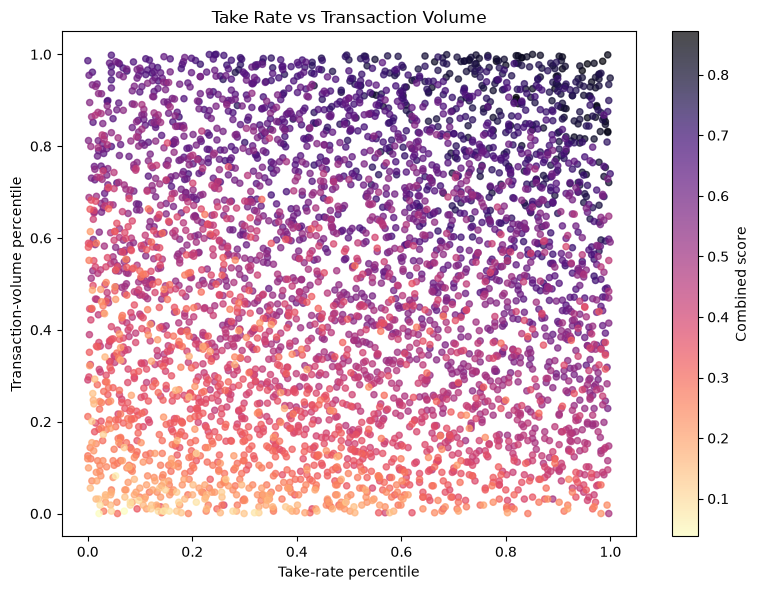

In [9]:
plot = ranking.select(
    "take_rate_score", "transaction_score", "ranking_score"
).toPandas()

fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(
    plot["take_rate_score"],
    plot["transaction_score"],
    c=plot["ranking_score"],
    cmap="magma_r",
    s=20,
    alpha=0.7,
)

ax.set_title("Take Rate vs Transaction Volume")
ax.set_xlabel("Take-rate percentile")
ax.set_ylabel("Transaction-volume percentile")

fig.colorbar(sc, ax=ax, label="Combined score")

plt.tight_layout()
plt.show()

/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


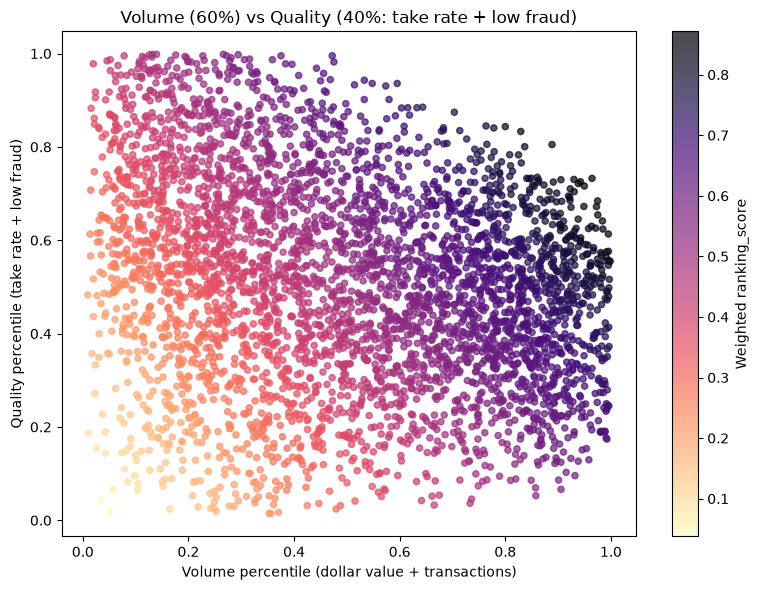

In [10]:
plot = ranking.select("volume_score", "quality_score", "ranking_score").toPandas()

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    plot["volume_score"], plot["quality_score"],
    c=plot["ranking_score"], cmap="magma_r", s=20, alpha=0.7,
)
ax.set_title(f"Volume ({VOLUME_WEIGHT:.0%}) vs Quality ({QUALITY_WEIGHT:.0%}: take rate + low fraud)")
ax.set_xlabel("Volume percentile (dollar value + transactions)")
ax.set_ylabel("Quality percentile (take rate + low fraud)")
fig.colorbar(sc, ax=ax, label="Weighted ranking_score")
plt.tight_layout()
plt.show()

# Train-Validate-Test Split

We learn ranking based on historical data then evaluate later data (no shuffle of time-series data)

In [11]:
train_size = 0.70
val_size = 0.15
test_size = 1 - train_size - val_size

date_bounds = df.select(
    F.min("order_datetime").alias("min_date"),
    F.max("order_datetime").alias("max_date")
).collect()[0]

min_date = date_bounds["min_date"]
max_date = date_bounds["max_date"]
total_days = (max_date - min_date).days

train_end = min_date + timedelta(days=int(total_days * train_size))
val_end = min_date + timedelta(days=int(total_days * (train_size + val_size)))

train_df = df.filter(F.col("order_datetime") <= train_end)
val_df = df.filter(
    (F.col("order_datetime") > train_end) &
    (F.col("order_datetime") <= val_end)
)
test_df = df.filter(F.col("order_datetime") > val_end)

print(f"Date range: {min_date} to {max_date} ({total_days} days)")
print(f"Train:      {min_date} to {train_end}")
print(f"Validation: {train_end} to {val_end}")
print(f"Test:       {val_end} to {max_date}")
print()
print(f"Train rows:      {train_df.count():,}")
print(f"Validation rows: {val_df.count():,}")
print(f"Test rows:       {test_df.count():,}")


Date range: 2021-02-28 to 2022-10-26 (605 days)
Train:      2021-02-28 to 2022-04-27
Validation: 2022-04-27 to 2022-07-27
Test:       2022-07-27 to 2022-10-26

Train rows:      9,045,528
Validation rows: 2,183,563
Test rows:       2,385,584


Build the ranking using train data only

In [12]:
train_summary = summarize_merchants(train_df)
train_scored = add_percentile_scores(train_summary)

train_ranked_volume = (
    compute_ranking_score(train_scored)
    .withColumn("rank", F.row_number().over(Window.orderBy(F.desc("ranking_score"))))
)

print("Top 20 merchants using TRAIN-period information only:")
train_ranked_volume.orderBy("rank").select(
    "rank", "merchant_abn", "merchant_name", "take_rate", "mean_fraud_probability",
    "total_dollar_value", "num_transactions",
    "volume_score", "quality_score", "ranking_score"
).show(truncate=False)

Top 20 merchants using TRAIN-period information only:


+----+------------+-----------------------------+---------+----------------------+------------------+----------------+------------------+------------------+------------------+
|rank|merchant_abn|merchant_name                |take_rate|mean_fraud_probability|total_dollar_value|num_transactions|volume_score      |quality_score     |ranking_score     |
+----+------------+-----------------------------+---------+----------------------+------------------+----------------+------------------+------------------+------------------+
|1   |63123845164 |Odio Phasellus Institute     |6.59     |11.570886106200383    |5698424.092455761 |7595            |0.9640904572564613|0.7326043737574552|0.8714960238568589|
|2   |71528203369 |Ipsum Primis Associates      |6.94     |13.432045732731677    |1246888.4627544037|21638           |0.9747763419483102|0.6842693836978131|0.8585735586481114|
|3   |38700038932 |Etiam Bibendum Industries    |6.31     |11.164228026866114    |6409454.65722117  |4787            |0.

# Evaluate ranking stability on the test period

We compare the train ranking against test-period transaction-volume ranks, using only merchants observed in both periods.

In [13]:
def make_test_summary(spark_df):
    return spark_df.groupBy("merchant_abn").agg(
        F.sum("dollar_value").alias("test_total_dollar_value"),
        F.count("order_id").alias("test_num_transactions"),
    )


test_summary = make_test_summary(test_df)

# Add actual test-period ranks.
test_ranked = (
    test_summary
    .withColumn(
        "test_dollar_rank",
        F.row_number().over(Window.orderBy(F.desc("test_total_dollar_value")))
    )
    .withColumn(
        "test_transaction_rank",
        F.row_number().over(Window.orderBy(F.desc("test_num_transactions")))
    )
)

# Compare the two candidate TRAIN rankings with the same TEST merchants.
eval_df = (
    train_ranked_volume.select(
        "merchant_abn", "rank", "ranking_score"
    )
    .withColumnRenamed("rank", "train_rank")
    .withColumnRenamed("ranking_score", "train_score")
    .join(test_ranked, on="merchant_abn", how="inner")
)

eval_pd = eval_df.select(
    "merchant_abn",
    "train_rank",
    "train_score",
    "test_dollar_rank",
    "test_transaction_rank",
).toPandas()

# Spearman rank correlation: higher magnitude means stronger rank agreement.
dollar_corr = eval_pd["train_rank"].corr(
    eval_pd["test_dollar_rank"], method="spearman"
)
tx_corr = eval_pd["train_rank"].corr(
    eval_pd["test_transaction_rank"], method="spearman"
)

print("\nRank stability")
print(f"take rate + dollar value + transactions vs test dollar rank: "
      f"{dollar_corr:.4f}")
print(f"ranking vs test transaction rank: "
      f"{tx_corr:.4f}")

/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()



Rank stability
take rate + dollar value + transactions vs test dollar rank: 0.7729
ranking vs test transaction rank: 0.8254



Top-K overlap: stronger TRAIN ranking vs TEST dollar-value ranking


Top  10: 0/10 merchants overlap


Top  25: 3/25 merchants overlap


Top  50: 10/50 merchants overlap


Top 100: 31/100 merchants overlap


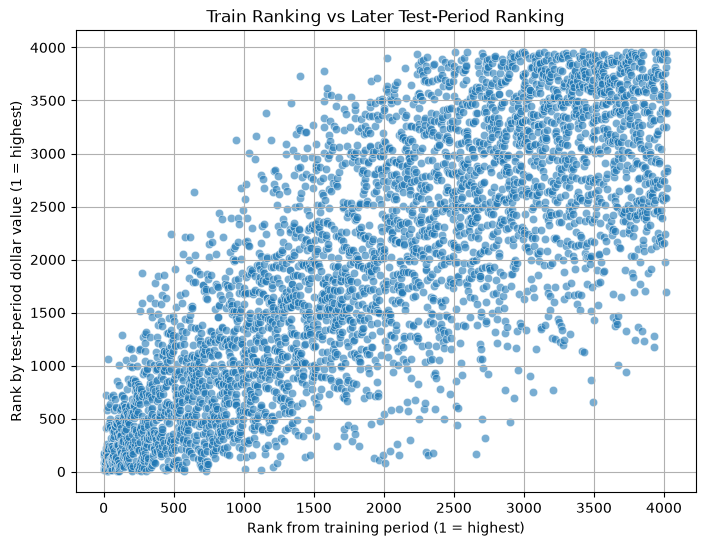

In [14]:
# Top-K overlap measures whether the ranking identifies merchants that remain among the strongest performers later.
def top_k_overlap(train_rank_df, test_rank_df, k):
    train_top = {
        r["merchant_abn"]
        for r in train_rank_df.orderBy("rank").limit(k).select("merchant_abn").collect()
    }
    test_top = {
        r["merchant_abn"]
        for r in test_rank_df.orderBy("test_dollar_rank").limit(k).select("merchant_abn").collect()
    }
    return len(train_top.intersection(test_top)), len(train_top), len(test_top)

print("\nTop-K overlap: stronger TRAIN ranking vs TEST dollar-value ranking")
for k in [10, 25, 50, 100]:
    overlap, train_n, test_n = top_k_overlap(train_ranked_volume, test_ranked, k)
    print(f"Top {k:>3}: {overlap}/{k} merchants overlap")

# Visual check of rank stability.
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=eval_pd,
    x="train_rank",
    y="test_dollar_rank",
    alpha=0.6,
)
plt.title("Train Ranking vs Later Test-Period Ranking")
plt.xlabel("Rank from training period (1 = highest)")
plt.ylabel("Rank by test-period dollar value (1 = highest)")
plt.grid()
plt.show()
